In [257]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [258]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [259]:
# # signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

# def calculate_sig_eff_err(eff, N_gen):

#     error = math.sqrt(eff * (1 - eff) / N_gen)
#     return error

In [260]:
def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
    central_value = (x+y)/2
    error = sqrt(x_err**2 +  y_err**2)/2
    return central_value, error

In [261]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [262]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

# MC15 full

## Acp(D+ -> eta pi+)

### eta -> gg

In [263]:
# Araw_gg_cms_plus = 0.0012959561431535693
# Araw_gg_cms_plus_error = 0.008847296239801952
# Araw_gg_cms_minus = 0.0036265431233290773
# Araw_gg_cms_minus_error =  0.01007268655495213
# Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [85]:
#new FOM

In [142]:
Araw_gg_cms_plus = -0.0032706976210071024
Araw_gg_cms_plus_error = 0.009053790486111457
Araw_gg_cms_minus = 0.011758696682473806
Araw_gg_cms_minus_error =  0.010382605296503512
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [143]:
Araw_gg

0.004243999530733351

In [144]:
Araw_gg_stats_error

0.006887844635831029

In [145]:
# Aref_gg_cms_plus = 0.004278295961374453
# Aref_gg_cms_plus_error = 0.0026385238818899975
# Aref_gg_cms_minus = 0.008913402855709032
# Aref_gg_cms_minus_error = 0.0028728539665111344
# Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [146]:
#new FOM

In [147]:
Aref_gg_cms_plus = -0.005678359996680358
Aref_gg_cms_plus_error = 0.00240215017340603
Aref_gg_cms_minus = 0.009484673404090085
Aref_gg_cms_minus_error = 0.0026131473764643455
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [148]:
Aref_gg

0.0019031567037048635

In [149]:
Aref_gg_stats_error

0.0017747439721490191

In [150]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717

Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [151]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [152]:
Acp_etapip_gg_value

-0.0024591571729715126

In [153]:
Acp_etapip_gg_error

0.007112813781762149

### eta -> pipipi

In [154]:
#new FOM

In [155]:
Araw_3pi_cms_plus = -0.005772694669676545
Araw_3pi_cms_plus_error = 0.011756625772863162
Araw_3pi_cms_minus =  0.01077962553653157
Araw_3pi_cms_minus_error =  0.012908492064499108
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [156]:
Aref_3pi_cms_plus = -0.00584138285513773
Aref_3pi_cms_plus_error =  0.0022762814864380216
Aref_3pi_cms_minus = 0.00955644151164052
Aref_3pi_cms_minus_error =  0.002487296355608174
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [157]:
Aref_pipipi

0.0018575293282513954

In [158]:
Aref_pipipi_stats_error

0.0016858306977661037

In [159]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [160]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [161]:
Acp_etapip_pipipi_value

-0.004154063894823883

In [162]:
Acp_etapip_pipipi_error

0.008891224852467024

In [163]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

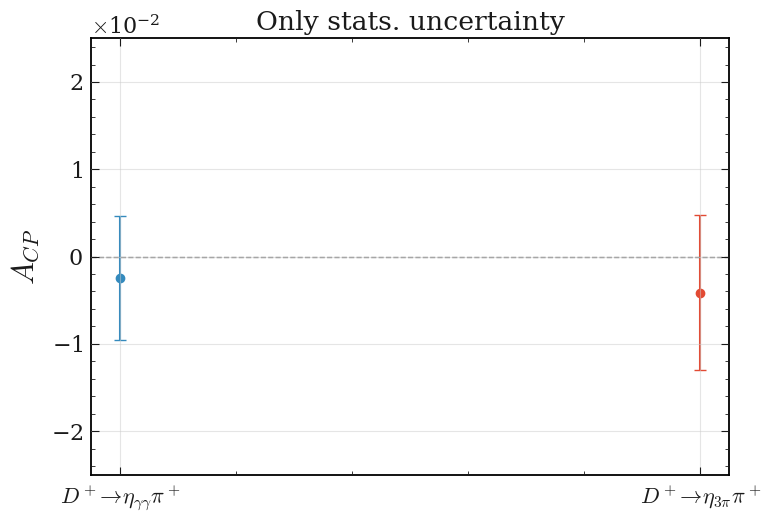

In [164]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix.png")
plt.show()

In [165]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [166]:
combined_central_value

-0.003120565350340737

In [167]:
combined_error

0.005554225044073275

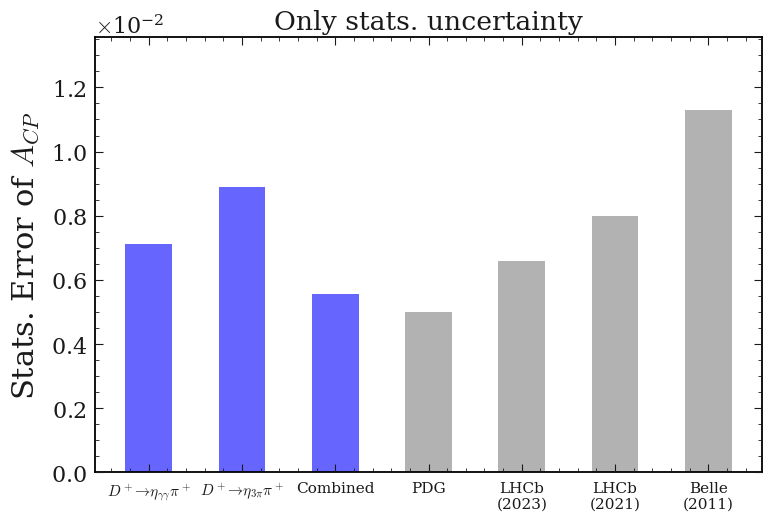

In [168]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
# plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Kshp.png")
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix.png")

plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [169]:
# Araw_gg_cms_plus = -0.0053327281907507885
# Araw_gg_cms_plus_error = 0.005377722641741649
# Araw_gg_cms_minus = 0.011063820964013402
# Araw_gg_cms_minus_error = 0.006436174624073516
# Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [170]:
Araw_gg_cms_plus = -0.007492319488201662
Araw_gg_cms_plus_error = 0.005460815828709397
Araw_gg_cms_minus =0.01015320429523156
Araw_gg_cms_minus_error = 0.006110754601655171
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [171]:
Araw_gg

0.0013304424035149491

In [172]:
Araw_gg_stats_error

0.004097616115399689

In [173]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [174]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [175]:
Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

In [176]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [177]:
Acp_etapip_gg_value

-0.005372714300189914

In [178]:
Acp_etapip_gg_error

0.004465442194885353

### eta -> pipipi

In [179]:
# Araw_pipipi =  0.0003362131000147013
# Araw_pipipi_stats_error = 0.005709802050462188

In [180]:
#new FOM

In [181]:
Araw_3pi_cms_plus = -0.00451644053810603
Araw_3pi_cms_plus_error = 0.0075150898241485966
Araw_3pi_cms_minus = 0.008112588946920003
Araw_3pi_cms_minus_error = 0.00823604460348399
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [182]:
Aref_pipipi

0.0018575293282513954

In [183]:
Aref_pipipi_stats_error

0.0016858306977661037

In [184]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [185]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [186]:
Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [187]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [188]:
Acp_etapip_pipipi_value

-0.00485945512384441

In [189]:
Acp_etapip_pipipi_error

0.005824025805697502

In [190]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

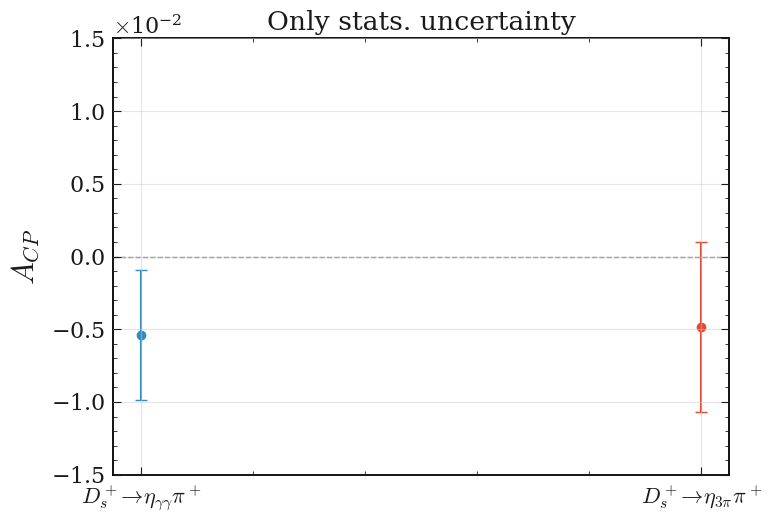

In [191]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
# plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_Phipip_Ds.png")
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()

In [192]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [193]:
combined_central_value

-0.005182692360291828

In [194]:
combined_error

0.003543698812017913

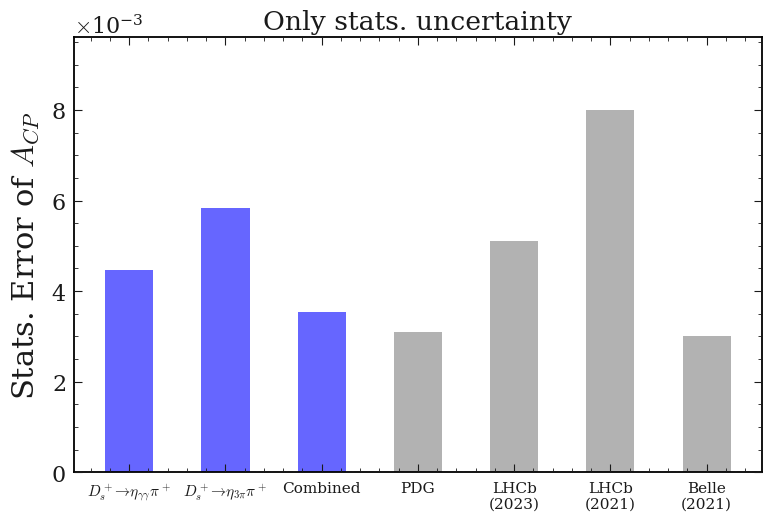

In [195]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
# plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Phipip_Ds.png")
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()


# proc13

## Acp(D+ -> eta pi+)

### eta -> gg

In [207]:
Araw_gg_cms_plus = 0
Araw_gg_cms_plus_error =  0.00812511461613611
Araw_gg_cms_minus = 0
Araw_gg_cms_minus_error =  0.00931090054941617
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [208]:
Araw_gg

0.0

In [209]:
Araw_gg_stats_error

0.006178801594291302

In [210]:
# Aref_gg_cms_plus = 
# Aref_gg_cms_plus_error = 
# Aref_gg_cms_minus = 
# Aref_gg_cms_minus_error =
# Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [211]:
Aref_gg

0.0019031567037048635

In [212]:
Aref_gg_stats_error

0.0017747439721490191

In [213]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717

Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [214]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [215]:
Acp_etapip_gg_value

-0.006703156703704864

In [216]:
Acp_etapip_gg_error

0.0064286316824263634

### eta -> pipipi

In [217]:
Araw_3pi_cms_plus = 0
Araw_3pi_cms_plus_error = 0.010831199018396322
Araw_3pi_cms_minus = 0
Araw_3pi_cms_minus_error =  0.012002145716082595
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [218]:
# Aref_3pi_cms_plus = 
# Aref_3pi_cms_plus_error = 
# Aref_3pi_cms_minus = 
# Aref_3pi_cms_minus_error =
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [219]:
Aref_pipipi

0.0018575293282513954

In [220]:
Aref_pipipi_stats_error

0.0016858306977661037

In [221]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [222]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [223]:
Acp_etapip_pipipi_value

-0.006657529328251396

In [224]:
Acp_etapip_pipipi_error

0.008257337260465862

In [225]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

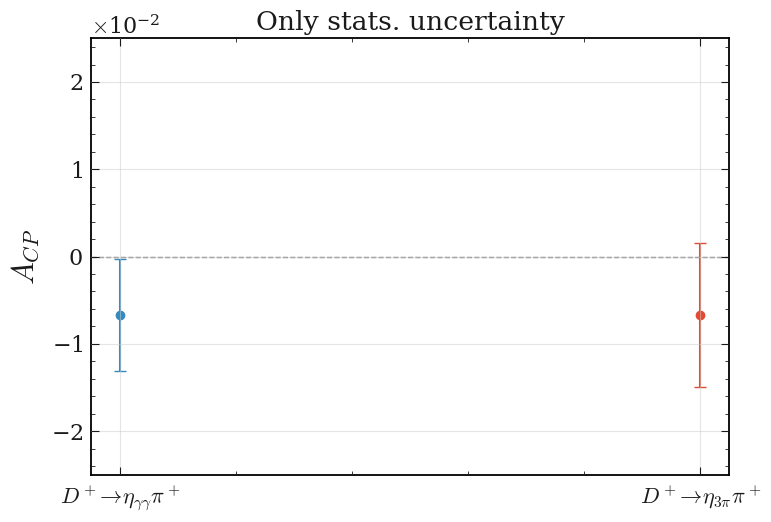

In [226]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("proc13_427_87_etapip_Acp_v7_fitv1_corr_Kshp_train_Dp_CMS_p_pdgKmix.png")
plt.show()

In [227]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [228]:
combined_central_value

-0.006685937814411306

In [229]:
combined_error

0.005072590989418199

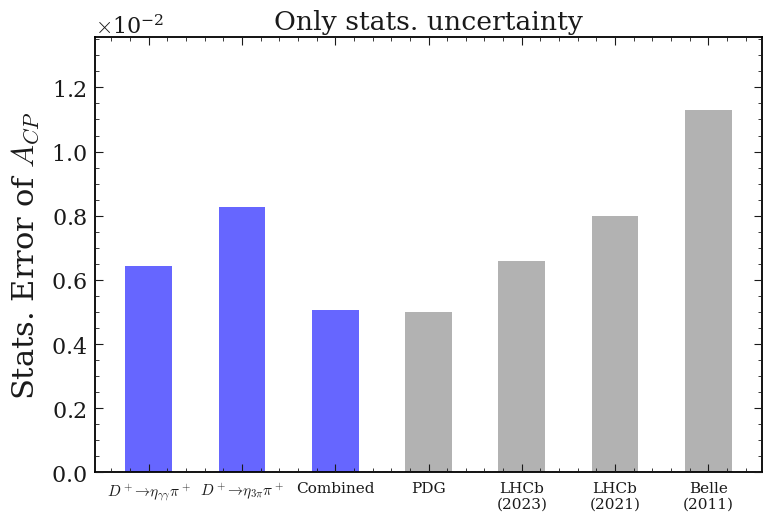

In [230]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("proc13_427_87_etapip_Acp_error_bars_v7_fitv11_corr_Kshp_train_Dp_CMS_p_pdgKmix.png")

plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [231]:
Araw_gg_cms_plus = 0
Araw_gg_cms_plus_error =  0.005659374015032616
Araw_gg_cms_minus = 0
Araw_gg_cms_minus_error =  0.0064510658664805945
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [232]:
Araw_gg

0.0

In [233]:
Araw_gg_stats_error

0.0042908264080389405

In [234]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [235]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [236]:
Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

In [237]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [238]:
Acp_etapip_gg_value

-0.006703156703704864

In [239]:
Acp_etapip_gg_error

0.004643372419977062

### eta -> pipipi

In [240]:
# Araw_pipipi =  0.0003362131000147013
# Araw_pipipi_stats_error = 0.005709802050462188

In [241]:
Araw_3pi_cms_plus = 0
Araw_3pi_cms_plus_error = 0.00789388155746653
Araw_3pi_cms_minus = 0
Araw_3pi_cms_minus_error = 0.008709803158101947
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [255]:
Araw_pipipi

0.0

In [256]:
Araw_pipipi_stats_error

0.005877372650602326

In [242]:
# Aref_3pi_cms_plus = 
# Aref_3pi_cms_plus_error = 
# Aref_3pi_cms_minus = 
# Aref_3pi_cms_minus_error =
# Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [243]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [244]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [245]:
Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [246]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [247]:
Acp_etapip_pipipi_value

-0.006657529328251396

In [248]:
Acp_etapip_pipipi_error

0.006114371138193916

In [249]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

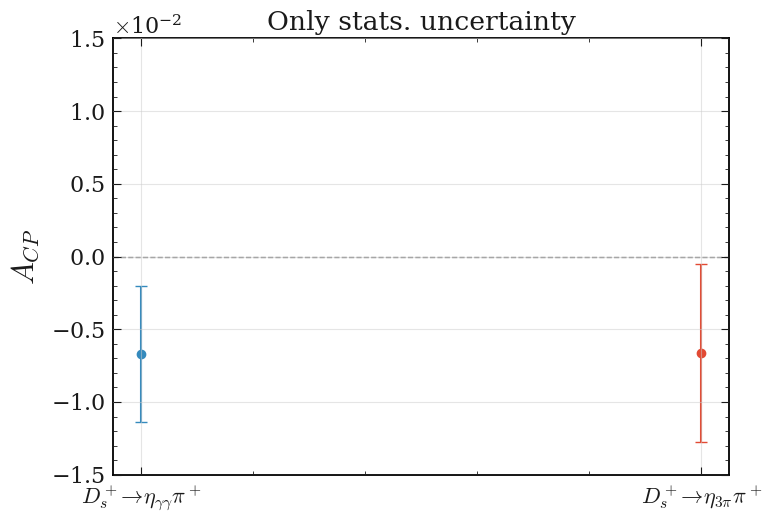

In [250]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
plt.savefig("proc13_427_87_etapip_Acp_v7_fitv1_corr_Kshp_train_Dp_CMS_p_pdgKmix_Ds.png")
plt.show()

In [251]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [252]:
combined_central_value

-0.006686467526417103

In [253]:
combined_error

0.0036979115278772626

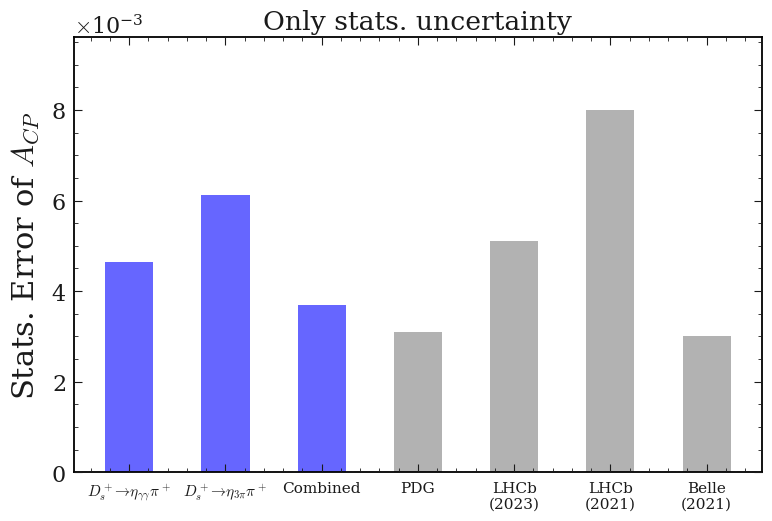

In [254]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
plt.savefig("proc13_427_87_etapip_Acp_error_bars_v7_fitv11_corr_Kshp_train_Dp_CMS_p_pdgKmix_Ds.png")
plt.show()
